In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:


def sigmoid(x) :
  return 1 / ( 1 + np.exp(-x))

class LogisticRegression : 
  def __init__(self, lr = 0.01, epochs = 1000) : 
    self.lr = lr
    self.epochs = epochs
    self.weights = None
    self.bias = 0

  def fit(self, X, y) : 
    n_samples, n_features = X.shape
    self.weights = np.zeros(n_features)
    self.bias = 0
    
    for _ in range(self.epochs) : 
      linear_pred = np.dot(X, self.weights) + self.bias
      y_pred = sigmoid(linear_pred)
      
      dw = (1 / n_samples) * np.dot(X.T, (y_pred - y));
      db = (1 / n_samples) * np.sum(y_pred - y)

      self.weights = self.weights - self.lr * dw
      self.bias = self.bias - self.lr * db

    print(f"Weights : {self.weights}")
    print(f"Bias : {self.bias}")

  def predict(self, X) : 
    linear_pred = np.dot(X, self.weights) + self.bias
    y_pred = sigmoid(linear_pred)
    return [0 if y <= 0.5 else 1 for y in y_pred]



In [3]:
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train ,y_test = train_test_split(X, y, train_size=0.8, random_state=1234)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Classification report : ");
print(classification_report(y_test, y_pred))


      

Weights : [ 3.07161176e+00  4.20734020e+00  1.77639350e+01  7.01794312e+00
  2.74028680e-02 -1.57147281e-02 -5.82889107e-02 -2.41821451e-02
  5.36128781e-02  2.20569258e-02  1.42153248e-02  2.91479889e-01
 -1.17835900e-01 -7.96111773e+00  1.36058955e-03 -4.73551318e-03
 -7.51627946e-03 -1.06664192e-03  5.40657749e-03  1.48729412e-04
  3.25590422e+00  5.34700588e+00  1.78141194e+01 -9.59918420e+00
  3.37293702e-02 -6.58592728e-02 -1.23854777e-01 -2.86160987e-02
  7.57456792e-02  1.91510130e-02]
Bias : 0.4004393943393561
Classification report : 
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        45
           1       0.92      0.96      0.94        69

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.92       114
weighted avg       0.92      0.92      0.92       114



C:\Users\RAJ SINGH\AppData\Local\Temp\ipykernel_8540\3849333639.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / ( 1 + np.exp(-x))


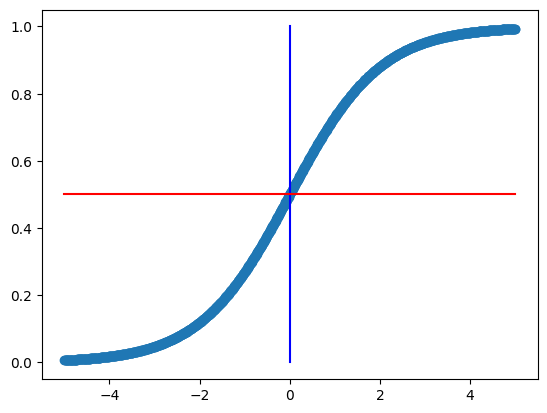

In [7]:
# c = -5
# x = []
# while(c <= 5) : 
#   x.append(c)
#   c += 0.01

x = np.linspace(-5, 5, 1000)

y = [sigmoid(xi) for xi in x]
plt.scatter(x, y) 
plt.plot([0, 0], [0, 1], c="b")
plt.plot([-5, 5], [0.5, 0.5], c="r")
plt.show()